# Ratings Descriptive Analysis

This notebook merges the three ratings files into one dataframe and keeps reusable helper functions in one place, so later descriptive analysis cells can stay short.

In [184]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.3f}".format)

preferred_fonts = [
    "PingFang SC",
    "Hiragino Sans GB",
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

DATA_FILES = [
    Path("huxiaoli_ipad_ratings.csv"),
    Path("miquan_ipad_ratings.csv"),
    Path("miquan_ratings.csv"),
]

RATING_COLUMNS = [
    "overall_rating", "剧情", "推理", "悬疑", "欢乐", "情感", "机制", "还原",
    "沉浸", "演绎", "玩法", "故事", "难度", "互动", "立意", "阵营",
    "本格", "变格", "恐怖", "硬核",
]
COUNT_COLUMNS = ["want_count", "played_count", "review_count"]

## Helper Functions

In [185]:
def load_rating_file(path: Path) -> pd.DataFrame:
    """Load one ratings CSV and add source metadata."""
    df = pd.read_csv(path, encoding="utf-8-sig")
    df.columns = df.columns.str.strip()
    df["source_file"] = path.name
    df["source_app"] = "huxiaoli" if "huxiaoli" in path.stem else "miquan"
    df["source_platform"] = "ipad" if "ipad" in path.stem else "mobile"
    return df


def merge_rating_files(paths: list[Path]) -> pd.DataFrame:
    """Merge ratings files with consistent column order and numeric types."""
    merged = pd.concat([load_rating_file(path) for path in paths], ignore_index=True, sort=False)
    numeric_columns = [col for col in RATING_COLUMNS + COUNT_COLUMNS if col in merged.columns]
    merged[numeric_columns] = merged[numeric_columns].apply(pd.to_numeric, errors="coerce")
    return merged


def summarize_missing(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.isna()
        .sum()
        .to_frame("missing_count")
        .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
        .sort_values("missing_count", ascending=False)
    )


def summarize_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    available_columns = [col for col in columns if col in df.columns]
    return df[available_columns].describe().T

## Load And Merge

In [186]:
ratings = merge_rating_files(DATA_FILES)

print(f"Merged rows: {len(ratings):,}")
print(f"Columns: {ratings.shape[1]:,}")
ratings.head()

Merged rows: 3,379
Columns: 31


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
0,龙傲天,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1,蜕变俱乐部2,蜕变俱乐部2：海的女儿,7.200,7.100,0.000,0.000,0.000,6.500,6.900,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,7607.000,14689.000,198,阿斯巴甜,4男3女 4.0小时 高阶 2020.08发行,欧美 机制 沉浸 童话,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
2,今夕何夕,今夕何夕,6.700,7.000,6.400,0.000,0.000,6.900,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.800,19494.000,250,KEYS工作室,5男2女 4.5小时 进阶 2020.08发行,古风 推理 沉浸 家国,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
3,蜕变俱乐部,蜕变俱乐部,7.300,7.200,0.000,7.100,0.000,0.000,7.100,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.600,17865.000,239,阿斯巴甜,4男3女 5.0小时 高阶 2020.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
4,土狗,土狗,8.000,7.700,0.000,7.600,0.000,0.000,0.000,8.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,5049.000,37782.000,5692,解语花剧本工作室,4男2女 7.0小时 进阶 2025.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad


In [187]:
ratings["source_file"].value_counts().rename_axis("source_file").to_frame("rows")

,rows
source_file,
miquan_ipad_ratings.csv,1657
huxiaoli_ipad_ratings.csv,1316
miquan_ratings.csv,406


## Duplicate Check

In [188]:
duplicate_keys = ["query"]
duplicate_mask = ratings.duplicated(subset=duplicate_keys, keep=False)

print(f"Rows sharing query: {duplicate_mask.sum():,}")
ratings.loc[duplicate_mask].sort_values(duplicate_keys).head(10)

Rows sharing query: 807


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
484,239二三九,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1513,239二三九,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ipad_ratings.csv,miquan,ipad
3328,239二三九,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ratings.csv,miquan,mobile
507,90后才不会变老呢,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1395,90后才不会变老呢,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ipad_ratings.csv,miquan,ipad
3099,90后才不会变老呢,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ratings.csv,miquan,mobile
3004,Hi老妖婆,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ratings.csv,miquan,mobile
1340,Hi老妖婆,HI！老妖婆,7.400,7.200,0.000,0.000,7.400,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,16909.000,18609.000,808,气球文娱,3男3女 4.0小时 新手 2023.02发行,【剧本杀测评】 📖剧本名称：HI！老妖婆 👫🏼游戏人数：3男3女（可反串） ⏰游戏时长：4h...,miquan_ipad_ratings.csv,miquan,ipad
2606,IDO,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,miquan_ipad_ratings.csv,miquan,ipad
185,IDO,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad


In [189]:
rating_columns = [col for col in RATING_COLUMNS if col in ratings.columns]
has_nonzero_rating = (
    ratings[rating_columns].fillna(0).ne(0).any(axis=1)
    if rating_columns
    else pd.Series(False, index=ratings.index)
)

ratings_with_rating_flag = ratings.assign(_has_nonzero_rating=has_nonzero_rating)
keep_indices = []
for _, group in ratings_with_rating_flag.groupby("query", sort=False):
    nonzero_indices = group.index[group["_has_nonzero_rating"]]
    if len(nonzero_indices) > 0:
        keep_indices.extend(nonzero_indices.tolist())
    else:
        keep_indices.append(group.index[0])

ratings_deduped = ratings_with_rating_flag.loc[keep_indices].drop(columns="_has_nonzero_rating")

print(f"Rows after dedupe preference: {len(ratings_deduped):,}")
ratings_deduped.head()

Rows after dedupe preference: 2,957


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
0,龙傲天,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,0.000,0.000,0,NaN,NaN,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
1,蜕变俱乐部2,蜕变俱乐部2：海的女儿,7.200,7.100,0.000,0.000,0.000,6.500,6.900,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,7607.000,14689.000,198,阿斯巴甜,4男3女 4.0小时 高阶 2020.08发行,欧美 机制 沉浸 童话,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
2,今夕何夕,今夕何夕,6.700,7.000,6.400,0.000,0.000,6.900,0.000,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.800,19494.000,250,KEYS工作室,5男2女 4.5小时 进阶 2020.08发行,古风 推理 沉浸 家国,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
3,蜕变俱乐部,蜕变俱乐部,7.300,7.200,0.000,7.100,0.000,0.000,7.100,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,2.600,17865.000,239,阿斯巴甜,4男3女 5.0小时 高阶 2020.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad
4,土狗,土狗,8.000,7.700,0.000,7.600,0.000,0.000,0.000,8.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,5049.000,37782.000,5692,解语花剧本工作室,4男2女 7.0小时 进阶 2025.06发行,NaN,huxiaoli_ipad_ratings.csv,huxiaoli,ipad


In [190]:
query_counts = ratings_deduped["query"].value_counts()
duplicate_query_counts = query_counts[query_counts > 1]

affected_queries = duplicate_query_counts.index.tolist()
print(f"Duplicate query names remaining in ratings_deduped: {len(duplicate_query_counts):,}")
if duplicate_query_counts.empty:
    print("No duplicate queries remain.")
else:
    print("Duplicate query row(s):")
    for query in affected_queries:
        rows = ratings_deduped.loc[ratings_deduped["query"] == query]
        print(f"\nQuery: {query}")
        print(rows.to_string(index=False))

Duplicate query names remaining in ratings_deduped: 1
Duplicate query row(s):

Query: 绣春刀
query script_title  overall_rating    剧情    推理    悬疑    欢乐    情感    机制    还原    沉浸    演绎    玩法  故事  难度  互动    立意    阵营  本格  变格  恐怖  硬核  want_count  played_count  review_count publishers      metadata        tags             source_file source_app source_platform
  绣春刀          绣春刀           7.100 7.100 0.000 0.000 0.000 7.100 6.900 0.000 0.000 0.000 0.000   0   0   0 0.000 0.000   0   0   0   0    7609.000      3477.000            62  一闪工作室; 草庐 3男4女 4.5小时 新手 古风 机制 沉浸 武侠 miquan_ipad_ratings.csv     miquan            ipad
  绣春刀          绣春刀           7.100 7.100 0.000 0.000 0.000 7.100 6.900 0.000 0.000 0.000 0.000   0   0   0 0.000 0.000   0   0   0   0    7609.000      3473.000            62  一闪工作室; 草庐 3男4女 4.5小时 新手 古风 机制 沉浸 武侠      miquan_ratings.csv     miquan          mobile


In [191]:
ratings_deduped = ratings_deduped.loc[~(
    (ratings_deduped["query"] == "绣春刀")
    & (ratings_deduped["source_file"] == "miquan_ratings.csv")
)].copy()

ratings_clean = ratings_deduped.loc[ratings_deduped["overall_rating"].gt(1)].copy()
ratings_no_zero_one = ratings_clean

print(f"Rows after dropping the second 绣春刀 row: {len(ratings_deduped):,}")
print(f"Rows in ratings_clean with overall_rating > 1: {len(ratings_clean):,}")
ratings_deduped[ratings_deduped["query"] == "绣春刀"]

Rows after dropping the second 绣春刀 row: 2,956
Rows in ratings_clean with overall_rating > 1: 2,108


,query,script_title,overall_rating,剧情,推理,悬疑,欢乐,情感,机制,还原,沉浸,演绎,玩法,故事,难度,互动,立意,阵营,本格,变格,恐怖,硬核,want_count,played_count,review_count,publishers,metadata,tags,source_file,source_app,source_platform
1316,绣春刀,绣春刀,7.100,7.100,0.000,0.000,0.000,7.100,6.900,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0,0,0,0,7609.000,3477.000,62,一闪工作室; 草庐,3男4女 4.5小时 新手,古风 机制 沉浸 武侠,miquan_ipad_ratings.csv,miquan,ipad


### Interpretation

After duplicate handling, the dataset drops from 3,379 merged rows to 2,956 deduplicated rows. Filtering out `overall_rating <= 1` leaves 2,108 scripts for analysis, so roughly one-third of the merged rows are not usable as rated scripts.


## Basic Summary

In [192]:
basic_stats_columns = RATING_COLUMNS + COUNT_COLUMNS
filtered_basic_stats = summarize_numeric(ratings_clean, basic_stats_columns)

print(f"Scripts in ratings_clean: {len(ratings_clean):,}")
print(f"Columns included in basic stats: {len([col for col in basic_stats_columns if col in ratings_clean.columns]):,}")
filtered_basic_stats

Scripts in ratings_clean: 2,108
Columns included in basic stats: 23


,count,mean,std,min,25%,50%,75%,max
overall_rating,2108.000,6.909,1.373,2.000,6.200,7.000,7.800,10.000
剧情,2108.000,5.487,2.908,0.000,5.900,6.800,7.225,8.900
推理,2108.000,2.351,3.274,0.000,0.000,0.000,6.400,8.900
悬疑,2108.000,0.902,2.337,0.000,0.000,0.000,0.000,8.600
欢乐,2108.000,1.034,2.481,0.000,0.000,0.000,0.000,8.600
情感,2108.000,1.866,3.146,0.000,0.000,0.000,6.125,8.900
机制,2108.000,1.033,2.439,0.000,0.000,0.000,0.000,8.900
还原,2108.000,0.565,1.939,0.000,0.000,0.000,0.000,8.600
沉浸,2108.000,0.971,2.466,0.000,0.000,0.000,0.000,8.900
演绎,2108.000,0.473,1.819,0.000,0.000,0.000,0.000,8.700


### Interpretation

The cleaned ratings center around 7.0: mean `overall_rating` is 6.91, median is 7.00, and the middle 50% of scripts run from 6.2 to 7.8. Popularity is much more uneven than ratings: median `played_count` is about 10,269, but the maximum is 344,824; median `review_count` is 363, but the maximum is 49,388.

The subcategory columns are sparse. `剧情` is the only subcategory with broad coverage in this basic table; many others have medians of 0 because most scripts do not have a displayed score for that dimension.


## Rating Distributions

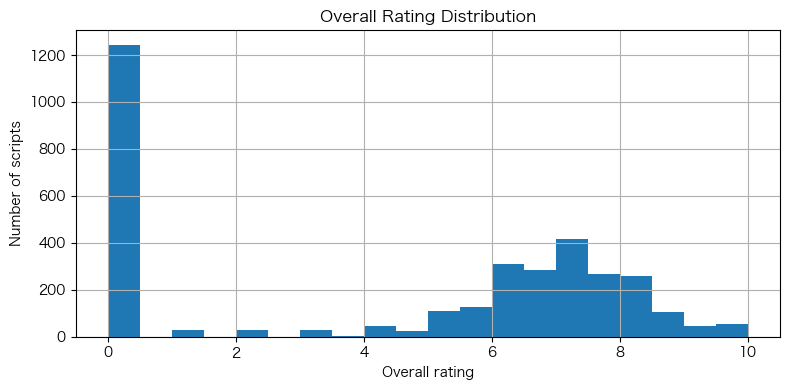

In [193]:
ratings["overall_rating"].hist(bins=20, figsize=(8, 4))
plt.title("Overall Rating Distribution")
plt.xlabel("Overall rating")
plt.ylabel("Number of scripts")
plt.tight_layout()

Overall rating 0/1 summary:
   count    pct
0   1243 36.786
1     27  0.799
Rows in ratings_clean with overall_rating > 1: 2,108


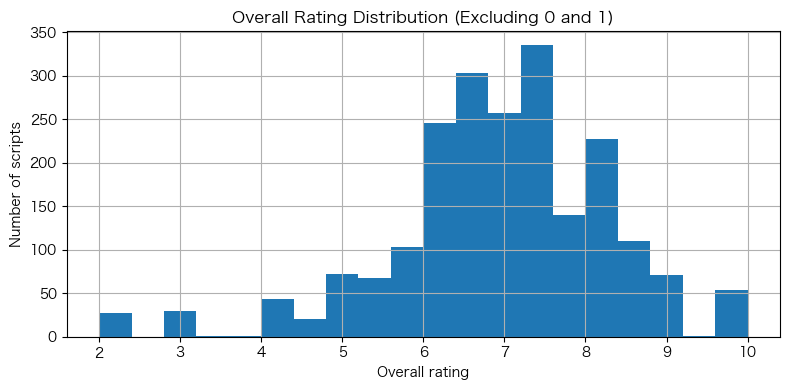

In [194]:
overall_rating = ratings["overall_rating"].dropna()
total_rows = len(overall_rating)
zero_count = (overall_rating == 0).sum()
one_count = (overall_rating == 1).sum()

rating_zero_one_summary = pd.DataFrame(
    {
        "count": [zero_count, one_count],
        "pct": [zero_count / total_rows * 100, one_count / total_rows * 100],
    },
    index=[0, 1],
)

print("Overall rating 0/1 summary:")
print(rating_zero_one_summary.to_string())

print(f"Rows in ratings_clean with overall_rating > 1: {len(ratings_clean):,}")

ratings_clean["overall_rating"].hist(bins=20, figsize=(8, 4))
plt.title("Overall Rating Distribution (Excluding 0 and 1)")
plt.xlabel("Overall rating")
plt.ylabel("Number of scripts")
plt.tight_layout()

### Interpretation

`overall_rating == 0` appears in 1,243 rows, or 36.8% of the merged data. Another 27 rows have `overall_rating == 1`. Since these rows have no meaningful played/review activity, the descriptive analysis relies on the 2,108 scripts with `overall_rating > 1`.


In [195]:
rating_one_scripts = ratings.loc[ratings["overall_rating"].eq(1), [
    "query",
    "script_title",
    "overall_rating",
    "source_file",
    "source_app",
    "source_platform",
    "played_count",
    "review_count",
    "tags",
]].sort_values(["query", "script_title", "source_file"])

print(f"Scripts with overall_rating == 1: {len(rating_one_scripts):,}")
rating_one_scripts

Scripts with overall_rating == 1: 27


,query,script_title,overall_rating,source_file,source_app,source_platform,played_count,review_count,tags
3011,不止清晨不止雾,不止清晨不止雾,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,中式 情感 沉浸 都市
1644,仙尽,仙尽,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,古风 推理 沉浸 武侠
1710,冰川之下,冰川之下,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN
346,吃来的爱,吃来的爱,1.000,huxiaoli_ipad_ratings.csv,huxiaoli,ipad,0.000,0,中式 推理 欢乐 科幻
3008,大丸子戏剧团,大丸子戏剧团,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,中式 其他 欢乐 新手
2367,天罚,天罚,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN
2329,寓盖弥彰,寓盖弥彰,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN
3149,心之所向,心之所向,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,架空 情感 沉浸 校园
3033,忘了忘不了,忘了忘不了,1.000,miquan_ratings.csv,miquan,mobile,0.000,0,NaN
2591,恶童,恶童,1.000,miquan_ipad_ratings.csv,miquan,ipad,0.000,0,NaN


### Interpretation

The 27 rows with `overall_rating == 1` all have `played_count == 0` and `review_count == 0`, so they look like incomplete scrape/app-result rows rather than genuinely low-rated scripts.


Note: some rating subcategories only have 0 values after filtering, so they are excluded from the plots below.
Zero-only subcategories: 故事, 难度, 互动, 本格, 变格, 恐怖, 硬核


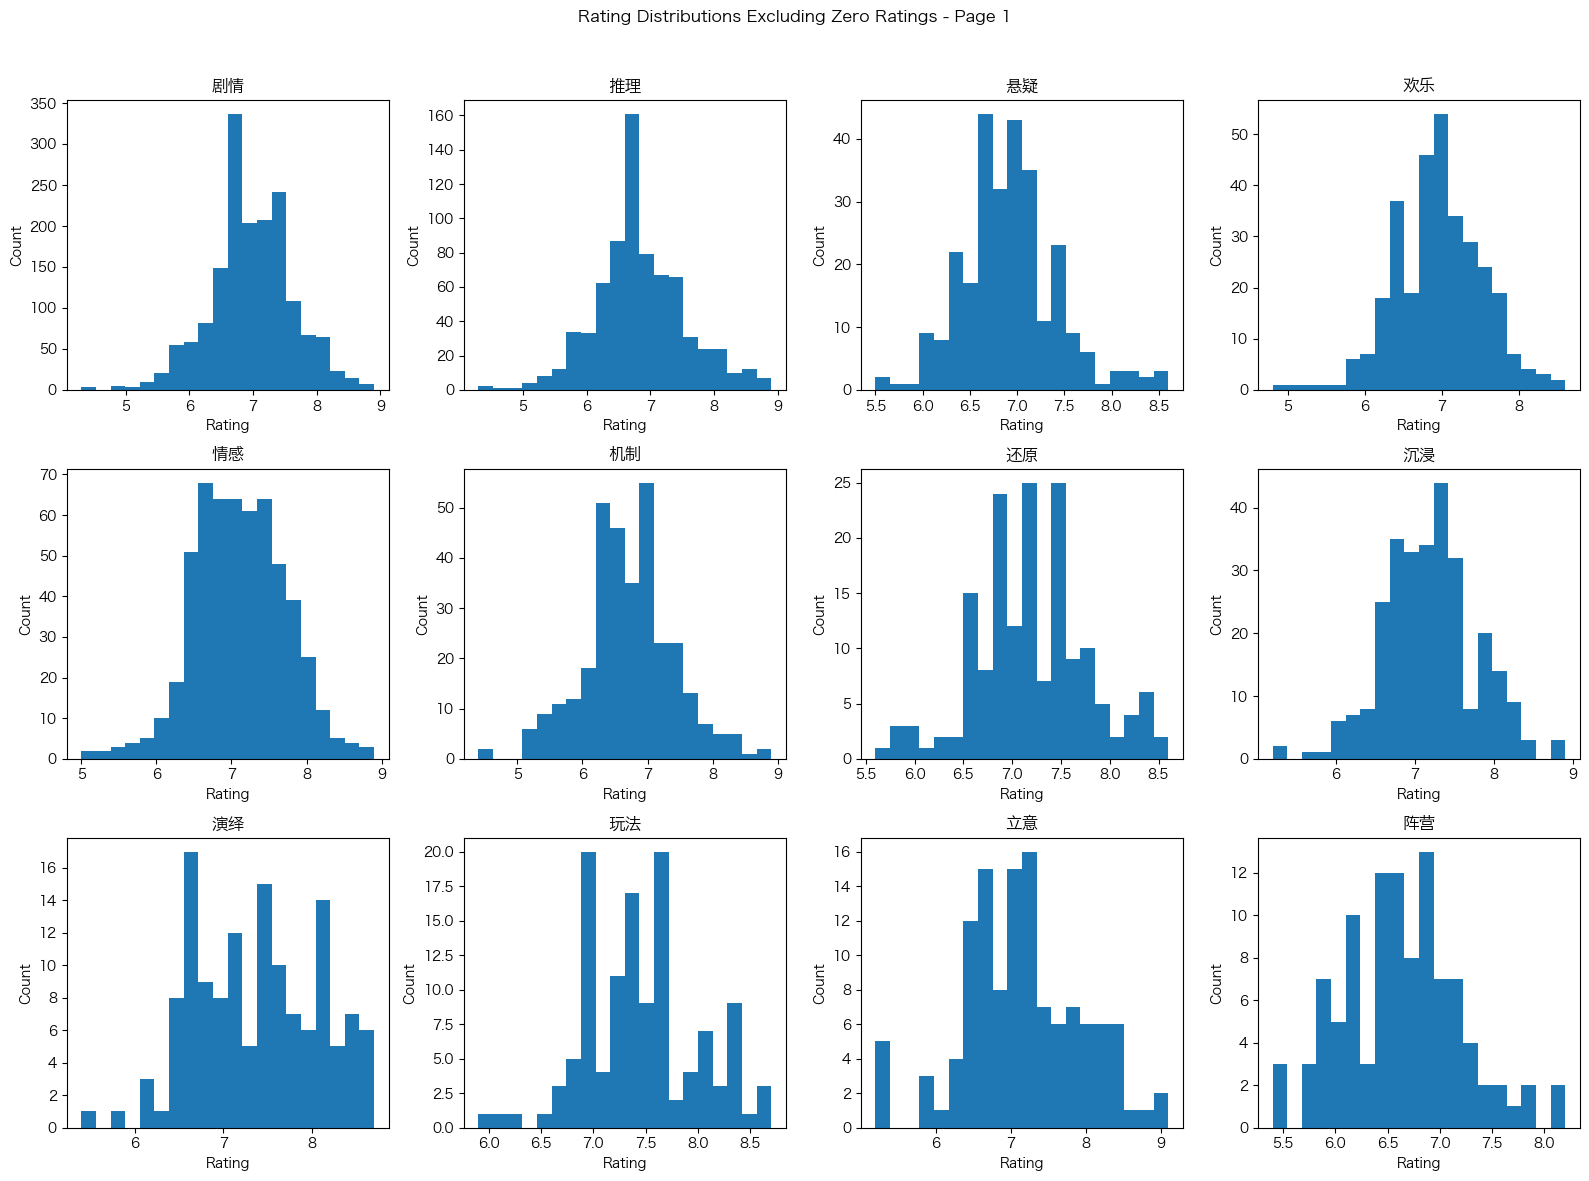

In [196]:
from matplotlib import font_manager
import math

preferred_fonts = [
    "PingFang SC",
    "Hiragino Sans GB",
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

rating_columns_no_overall = [col for col in RATING_COLUMNS if col != "overall_rating" and col in ratings.columns]
nonzero_rating_data = {
    col: ratings_no_zero_one[col].dropna().loc[lambda s: s.gt(0)]
    for col in rating_columns_no_overall
}
positive_rating_columns = [col for col in rating_columns_no_overall if not nonzero_rating_data[col].empty]
zero_only_columns = [col for col in rating_columns_no_overall if nonzero_rating_data[col].empty]

print("Note: some rating subcategories only have 0 values after filtering, so they are excluded from the plots below.")
if zero_only_columns:
    print("Zero-only subcategories: " + ", ".join(zero_only_columns))


def plot_rating_hist_page(columns: list[str], title: str) -> None:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        values = nonzero_rating_data[col]
        ax.hist(values, bins=20)
        ax.set_title(col)
        ax.set_xlabel("Rating")
        ax.set_ylabel("Count")

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)


page_size = 12
for page_number, start in enumerate(range(0, len(positive_rating_columns), page_size), start=1):
    page_columns = positive_rating_columns[start : start + page_size]
    plot_rating_hist_page(page_columns, f"Rating Distributions Excluding Zero Ratings - Page {page_number}")

## Popularity Variables

In [197]:
want_count = ratings_clean["want_count"]
suspicious_want_count_mask = (
    want_count.notna()
    & want_count.gt(0)
    & (want_count.lt(100) | ~np.isclose(want_count, np.round(want_count)))
)
ratings_popularity = ratings_clean.loc[~suspicious_want_count_mask].copy()

available_count_columns = [col for col in COUNT_COLUMNS if col in ratings_popularity.columns]

print(f"Rows in ratings_clean: {len(ratings_clean):,}")
print(f"Rows excluded for suspicious want_count: {suspicious_want_count_mask.sum():,}")
print(f"Rows in ratings_popularity: {len(ratings_popularity):,}")

popularity_summary = summarize_numeric(ratings_popularity, available_count_columns)
popularity_summary


Rows in ratings_clean: 2,108
Rows excluded for suspicious want_count: 920
Rows in ratings_popularity: 1,188


,count,mean,std,min,25%,50%,75%,max
want_count,1188.000,11045.419,20886.191,0.000,1314.250,5049.000,9443.500,199506.000
played_count,1186.000,24335.522,40510.346,0.000,2694.500,10044.500,27242.500,344824.000
review_count,1188.000,1610.979,3706.765,0.000,62.000,385.000,1534.250,49388.000


### Interpretation

The `want_count` cleaning rule removes 920 scripts from popularity-specific analysis, leaving 1,188 rows. After this filter, median `want_count` rises from 11.3 in `ratings_clean` to 5,049 in `ratings_popularity`, confirming that the small/random `want_count` values were distorting the distribution.

Even after cleaning `want_count`, popularity remains highly skewed: median `review_count` is 385, while the maximum is 49,388; median `played_count` is about 10,045, while the maximum is 344,824.


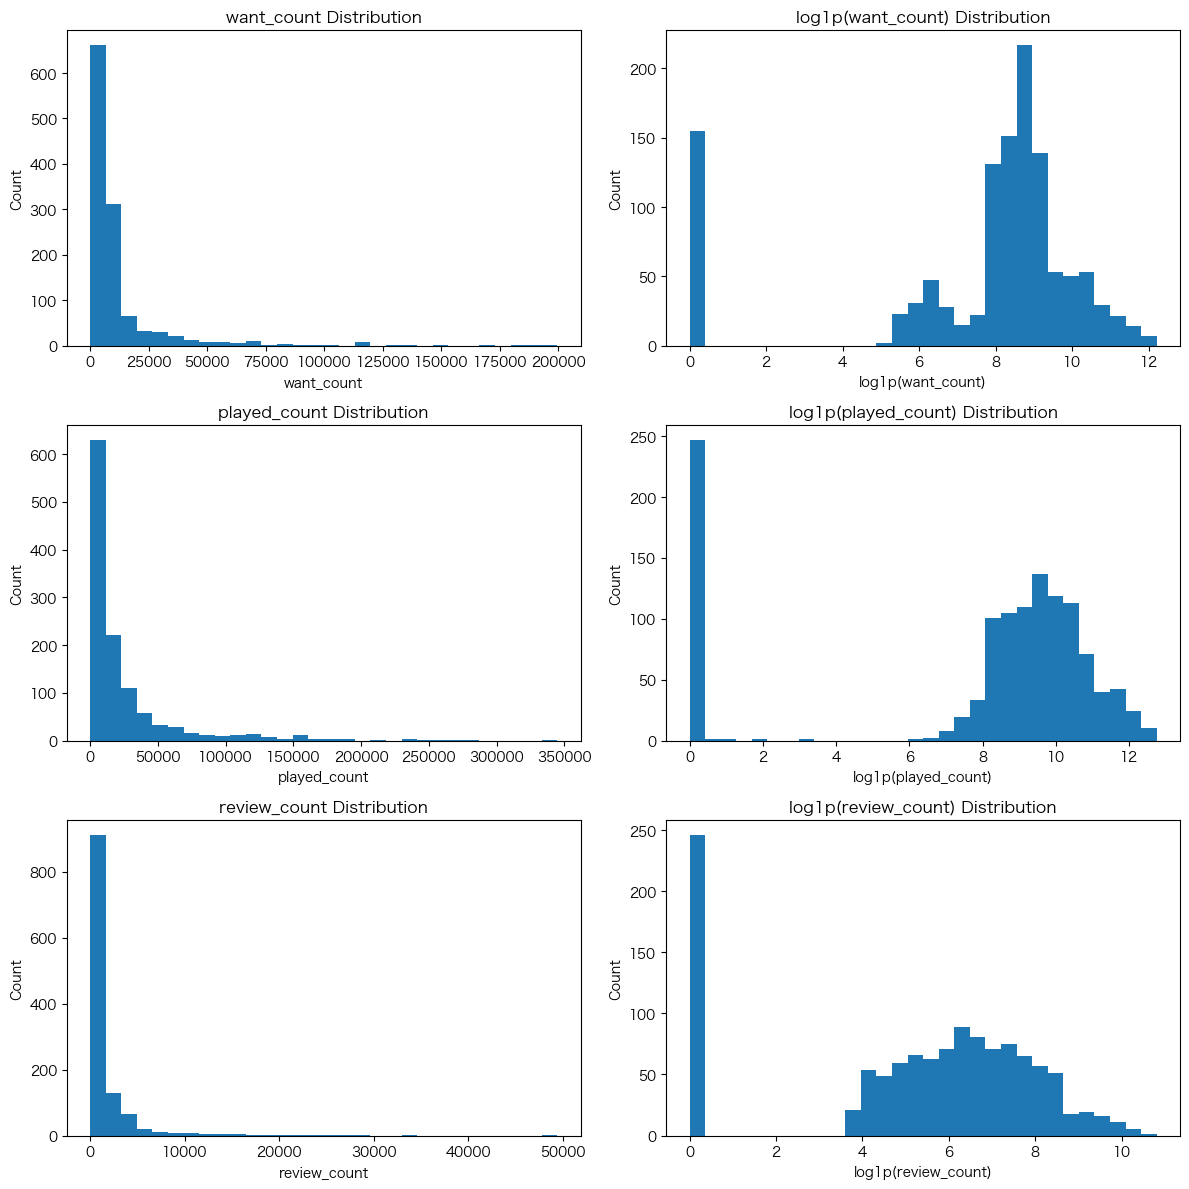

In [198]:
fig, axes = plt.subplots(len(available_count_columns), 2, figsize=(12, 4 * len(available_count_columns)))
if len(available_count_columns) == 1:
    axes = np.array([axes])

for row_index, col in enumerate(available_count_columns):
    values = ratings_popularity[col].dropna()
    axes[row_index, 0].hist(values, bins=30)
    axes[row_index, 0].set_title(f"{col} Distribution")
    axes[row_index, 0].set_xlabel(col)
    axes[row_index, 0].set_ylabel("Count")

    axes[row_index, 1].hist(np.log1p(values), bins=30)
    axes[row_index, 1].set_title(f"log1p({col}) Distribution")
    axes[row_index, 1].set_xlabel(f"log1p({col})")
    axes[row_index, 1].set_ylabel("Count")

fig.tight_layout()


## Rating Vs Popularity

In [199]:
popularity_correlation_rows = []

for col in available_count_columns:
    analysis_subset = ratings_popularity[["overall_rating", col]].dropna()
    popularity_correlation_rows.append(
        {
            "popularity_variable": col,
            "n": len(analysis_subset),
            "pearson_corr_with_overall_rating": analysis_subset["overall_rating"].corr(
                analysis_subset[col], method="pearson"
            ),
            "spearman_corr_with_overall_rating": analysis_subset["overall_rating"].corr(
                analysis_subset[col], method="spearman"
            ),
        }
    )

rating_popularity_correlations = pd.DataFrame(popularity_correlation_rows).sort_values(
    "spearman_corr_with_overall_rating",
    ascending=False,
)
rating_popularity_correlations


,popularity_variable,n,pearson_corr_with_overall_rating,spearman_corr_with_overall_rating
2,review_count,1188,0.344,0.509
1,played_count,1186,0.319,0.408
0,want_count,1188,0.256,0.268


### Interpretation

`review_count` has the strongest relationship with `overall_rating` among the popularity variables: Pearson = 0.344 and Spearman = 0.509. `played_count` is next, with Pearson = 0.319 and Spearman = 0.408. Cleaned `want_count` is weaker, with Pearson = 0.256 and Spearman = 0.268.

The rank-order relationships are stronger than the linear ones, especially for `review_count`, which fits the skewed popularity distributions: highly rated scripts tend to be more reviewed/popular, but the relationship is not simply linear.


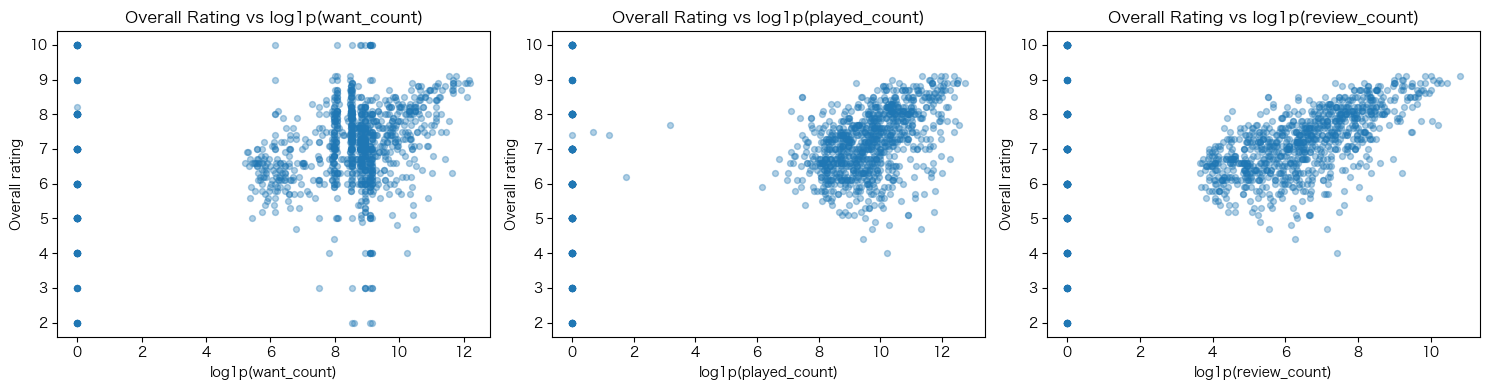

In [200]:
fig, axes = plt.subplots(1, len(available_count_columns), figsize=(5 * len(available_count_columns), 4))
if len(available_count_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, available_count_columns):
    ax.scatter(np.log1p(ratings_popularity[col]), ratings_popularity["overall_rating"], alpha=0.35, s=18)
    ax.set_title(f"Overall Rating vs log1p({col})")
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Overall rating")

fig.tight_layout()


## Weighted Ranking

In [201]:
ranking = ratings_popularity.copy()
ranking["review_count"] = ranking["review_count"].fillna(0)

global_mean_rating = ranking["overall_rating"].mean()
positive_review_counts = ranking.loc[ranking["review_count"].gt(0), "review_count"]
minimum_review_weight = positive_review_counts.median() if not positive_review_counts.empty else 1

ranking["weighted_rating"] = (
    (ranking["review_count"] / (ranking["review_count"] + minimum_review_weight)) * ranking["overall_rating"]
    + (minimum_review_weight / (ranking["review_count"] + minimum_review_weight)) * global_mean_rating
)

weighted_ranking_columns = [
    "query", "script_title", "overall_rating", "weighted_rating", "review_count",
    "played_count", "want_count", "source_app", "source_platform", "tags",
]

print(f"Global mean rating: {global_mean_rating:.3f}")
print(f"Review-count prior weight: {minimum_review_weight:.1f}")
ranking.sort_values("weighted_rating", ascending=False)[weighted_ranking_columns].head(20)


Global mean rating: 7.006
Review-count prior weight: 652.5


,query,script_title,overall_rating,weighted_rating,review_count,played_count,want_count,source_app,source_platform,tags
856,猫岛谋杀循环,猫岛谋杀循环,9.100,9.073,49388,236965.000,4838.000,huxiaoli,ipad,NaN
756,无相人考古奇案,无相人考古奇案,9.100,9.040,21958,126129.000,2984.000,huxiaoli,ipad,NaN
2496,月落洼,月落洼,9.100,9.029,18476,177845.000,128997.000,miquan,ipad,NaN
2747,孽岛疑云,孽岛疑云,9.100,8.983,10979,154527.000,101645.000,miquan,ipad,NaN
3057,风林火山,风林火山,9.100,8.956,8808,84552.000,3160.000,miquan,mobile,日式 机制 博弈 其他
2646,年轮,年轮,9.000,8.954,27715,276044.000,189696.000,miquan,ipad,中式 情感 沉浸 新手
850,死亡回响,死亡回响,9.000,8.946,23554,150790.000,4837.000,huxiaoli,ipad,日式 推理 悬疑 其他
3341,须臾,须臾,9.000,8.879,10105,105136.000,115266.000,miquan,mobile,NaN
1440,怪谈事务所破界,怪谈事务所：破界,9.000,8.879,10071,110545.000,3161.000,miquan,ipad,日式 机制 博弈 怪谈
1921,病娇男孩的精分日记,病娇男孩的精分日记,8.900,8.864,33926,344824.000,199506.000,miquan,ipad,NaN


### Interpretation

The top weighted scripts are high-rating/high-evidence titles rather than tiny-sample 10.0 scores. `猫岛谋杀循环` ranks first with `overall_rating = 9.1`, `review_count = 49,388`, and `weighted_rating = 9.073`. The top group is dominated by scripts rated 8.8-9.1 with thousands to tens of thousands of reviews, which makes the ranking much more credible than raw rating alone.


## Rating Subcategories

In [202]:
subcategory_columns = [col for col in RATING_COLUMNS if col != "overall_rating" and col in ratings_clean.columns]

subcategory_summary = pd.DataFrame(
    {
        "nonzero_count": ratings_clean[subcategory_columns].gt(0).sum(),
        "nonzero_pct": ratings_clean[subcategory_columns].gt(0).mean() * 100,
        "mean_nonzero_rating": ratings_clean[subcategory_columns].where(ratings_clean[subcategory_columns].gt(0)).mean(),
        "median_nonzero_rating": ratings_clean[subcategory_columns].where(ratings_clean[subcategory_columns].gt(0)).median(),
    }
).sort_values("nonzero_count", ascending=False)

subcategory_summary

,nonzero_count,nonzero_pct,mean_nonzero_rating,median_nonzero_rating
剧情,1660,78.748,6.968,7.000
推理,725,34.393,6.835,6.800
情感,553,26.233,7.113,7.100
机制,324,15.370,6.720,6.700
欢乐,314,14.896,6.941,6.900
沉浸,285,13.520,7.183,7.200
悬疑,275,13.046,6.917,6.900
还原,166,7.875,7.172,7.100
演绎,135,6.404,7.392,7.400
玩法,122,5.787,7.448,7.400


### Interpretation

`剧情` is present for 1,660 scripts, covering 78.7% of `ratings_clean`. The next most common subcategories are much less complete: `推理` appears in 725 scripts, `情感` in 553, `机制` in 324, and `欢乐` in 314.

Among nonzero subcategory scores, the highest means are `玩法` (7.45), `演绎` (7.39), `沉浸` (7.18), `还原` (7.17), and `立意` (7.16). Seven subcategory columns have no nonzero values at all, so they should be excluded from substantive interpretation.


In [203]:
subcategory_corr_rows = []

for col in subcategory_columns:
    analysis_subset = ratings_clean.loc[ratings_clean[col].gt(0), ["overall_rating", col]].dropna()
    if len(analysis_subset) >= 3:
        corr = analysis_subset["overall_rating"].corr(analysis_subset[col], method="spearman")
    else:
        corr = np.nan
    subcategory_corr_rows.append({"subcategory": col, "nonzero_count": len(analysis_subset), "spearman_corr": corr})

subcategory_overall_correlations = pd.DataFrame(subcategory_corr_rows).sort_values(
    "spearman_corr",
    ascending=False,
)
subcategory_overall_correlations

,subcategory,nonzero_count,spearman_corr
0,剧情,1660,0.935
9,玩法,122,0.924
7,沉浸,285,0.922
4,情感,553,0.915
13,立意,121,0.880
6,还原,166,0.870
2,悬疑,275,0.847
5,机制,324,0.845
3,欢乐,314,0.833
14,阵营,103,0.821


### Interpretation

All active subcategories are positively associated with `overall_rating`. The strongest Spearman correlations are `剧情` (0.935), `玩法` (0.924), `沉浸` (0.922), and `情感` (0.915). `演绎` is the weakest among active columns at 0.784, but that is still a strong relationship.

This suggests that overall rating is closely aligned with whichever detailed subcategory scores are available, especially story/experience dimensions.


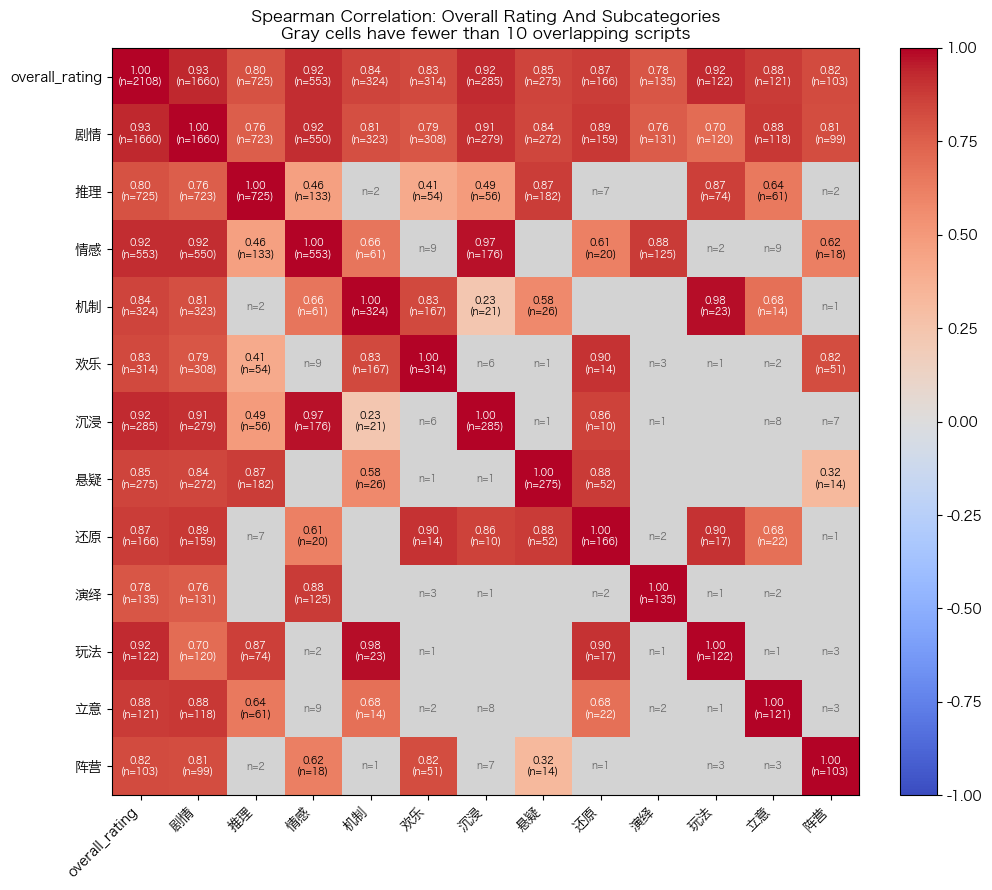

In [204]:
active_subcategory_columns = subcategory_summary.query("nonzero_count >= 10").index.tolist()
overall_and_subcategory_columns = ["overall_rating"] + active_subcategory_columns
min_pairwise_overlap = 10

corr_input = ratings_clean[overall_and_subcategory_columns].copy()
corr_input[active_subcategory_columns] = corr_input[active_subcategory_columns].replace(0, np.nan)
subcategory_corr_matrix = corr_input.corr(method="spearman")
rating_presence = corr_input.notna().astype(int)
pairwise_overlap_counts = rating_presence.T.dot(rating_presence)

masked_subcategory_corr_matrix = subcategory_corr_matrix.mask(
    pairwise_overlap_counts.lt(min_pairwise_overlap)
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(masked_subcategory_corr_matrix, vmin=-1, vmax=1, cmap=cmap)
ax.set_xticks(range(len(overall_and_subcategory_columns)))
ax.set_xticklabels(overall_and_subcategory_columns, rotation=45, ha="right")
ax.set_yticks(range(len(overall_and_subcategory_columns)))
ax.set_yticklabels(overall_and_subcategory_columns)
ax.set_title(
    f"Spearman Correlation: Overall Rating And Subcategories\n"
    f"Gray cells have fewer than {min_pairwise_overlap} overlapping scripts"
)

for row_idx in range(len(overall_and_subcategory_columns)):
    for col_idx in range(len(overall_and_subcategory_columns)):
        corr_value = masked_subcategory_corr_matrix.iloc[row_idx, col_idx]
        overlap_count = pairwise_overlap_counts.iloc[row_idx, col_idx]
        if pd.notna(corr_value):
            ax.text(
                col_idx,
                row_idx,
                f"{corr_value:.2f}\n(n={overlap_count})",
                ha="center",
                va="center",
                color="white" if abs(corr_value) >= 0.65 else "black",
                fontsize=7,
            )
        elif overlap_count > 0:
            ax.text(
                col_idx,
                row_idx,
                f"n={overlap_count}",
                ha="center",
                va="center",
                color="dimgray",
                fontsize=7,
            )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

### Interpretation

The heatmap shows broadly positive alignment among active subcategory scores. The strongest and most interpretable relationships are between `overall_rating` and core subcategories such as `剧情`, `玩法`, `沉浸`, and `情感`. Masked cells mean there were fewer than 10 scripts with both subcategory scores present, so the visible chart emphasizes relationships with enough overlapping data.


In [205]:
high_rating_cutoff = ratings_clean["overall_rating"].quantile(0.75)
mid_rating_cutoff = ratings_clean["overall_rating"].median()

profile_data = pd.DataFrame(
    {
        "high_rated_mean": ratings_clean.loc[
            ratings_clean["overall_rating"].ge(high_rating_cutoff), active_subcategory_columns
        ].replace(0, np.nan).mean(),
        "below_median_mean": ratings_clean.loc[
            ratings_clean["overall_rating"].lt(mid_rating_cutoff), active_subcategory_columns
        ].replace(0, np.nan).mean(),
    }
)
profile_data["difference"] = profile_data["high_rated_mean"] - profile_data["below_median_mean"]
profile_data = profile_data.sort_values("difference", ascending=False)

profile_data

,high_rated_mean,below_median_mean,difference
立意,8.034,6.379,1.655
演绎,8.244,6.854,1.391
剧情,7.737,6.440,1.297
阵营,7.660,6.369,1.291
机制,7.542,6.264,1.278
推理,7.629,6.365,1.263
情感,7.826,6.572,1.255
沉浸,7.836,6.640,1.197
欢乐,7.821,6.655,1.166
还原,7.796,6.658,1.138


### Interpretation

High-rated scripts separate most strongly from below-median scripts on `立意` (+1.66), `演绎` (+1.39), `剧情` (+1.30), `阵营` (+1.29), and `机制` (+1.28). `悬疑` has the smallest gap (+0.96). This suggests that high overall ratings are not just higher everywhere; the biggest differences show up in idea/theme, performance/hosting, story, faction, and mechanics dimensions.


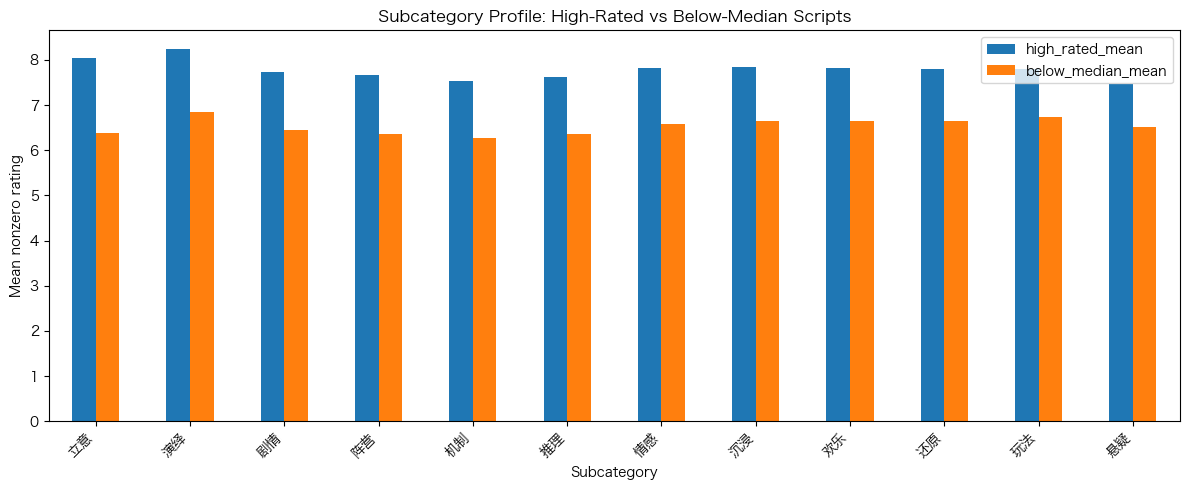

In [206]:
profile_data[["high_rated_mean", "below_median_mean"]].plot(kind="bar", figsize=(12, 5))
plt.title("Subcategory Profile: High-Rated vs Below-Median Scripts")
plt.xlabel("Subcategory")
plt.ylabel("Mean nonzero rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

## Subcategory Co-Occurrence

This section treats each nonzero subcategory rating as a subcategory assigned to that script. Because each script usually has only a small number of subcategories, co-occurrence can help identify common rating bundles and genre/design patterns.

In [207]:
from itertools import combinations

subcategory_presence = ratings_clean[active_subcategory_columns].gt(0)
subcategory_count_per_script = subcategory_presence.sum(axis=1)

subcategory_count_distribution = (
    subcategory_count_per_script
    .value_counts()
    .sort_index()
    .rename_axis("nonzero_subcategory_count")
    .to_frame("script_count")
)
subcategory_count_distribution["script_pct"] = (
    subcategory_count_distribution["script_count"] / len(subcategory_presence) * 100
)
subcategory_count_distribution

,script_count,script_pct
nonzero_subcategory_count,,
0,433,20.541
1,7,0.332
2,228,10.816
3,1440,68.311


### Interpretation

Most scripts with subcategory data have exactly three active subcategory ratings: 1,440 scripts, or 68.3% of `ratings_clean`. Another 433 scripts, or 20.5%, have no active subcategory ratings. This confirms that the platform is usually exposing a limited bundle of dimensions per script, rather than scoring every script on every dimension.


In [208]:
pair_rows = []
total_scripts = len(subcategory_presence)
subcategory_counts = subcategory_presence.sum()

for left, right in combinations(active_subcategory_columns, 2):
    both_count = (subcategory_presence[left] & subcategory_presence[right]).sum()
    left_count = subcategory_counts[left]
    right_count = subcategory_counts[right]

    if both_count == 0:
        continue

    support = both_count / total_scripts
    expected_support = (left_count / total_scripts) * (right_count / total_scripts)
    lift = support / expected_support if expected_support > 0 else np.nan
    jaccard = both_count / (left_count + right_count - both_count)

    pair_rows.append(
        {
            "subcategory_pair": f"{left} + {right}",
            "left": left,
            "right": right,
            "both_count": both_count,
            "support_pct": support * 100,
            "jaccard": jaccard,
            "lift": lift,
            "left_given_right_pct": both_count / right_count * 100,
            "right_given_left_pct": both_count / left_count * 100,
        }
    )

subcategory_pair_cooccurrence = pd.DataFrame(pair_rows)
common_subcategory_pairs = (
    subcategory_pair_cooccurrence
    .query("both_count >= 20")
    .sort_values(["lift", "both_count"], ascending=[False, False])
)
common_subcategory_pairs.head(20)

,subcategory_pair,left,right,both_count,support_pct,jaccard,lift,left_given_right_pct,right_given_left_pct
24,情感 + 演绎,情感,演绎,125,5.930,0.222,3.530,92.593,22.604
28,机制 + 欢乐,机制,欢乐,167,7.922,0.355,3.460,53.185,51.543
40,欢乐 + 阵营,欢乐,阵营,51,2.419,0.139,3.324,49.515,16.242
46,悬疑 + 还原,悬疑,还原,52,2.467,0.134,2.401,31.325,18.909
22,情感 + 沉浸,情感,沉浸,176,8.349,0.266,2.354,61.754,31.826
50,还原 + 立意,还原,立意,22,1.044,0.083,2.309,18.182,13.253
15,推理 + 悬疑,推理,悬疑,182,8.634,0.222,1.924,66.182,25.103
17,推理 + 玩法,推理,玩法,74,3.510,0.096,1.764,60.656,10.207
18,推理 + 立意,推理,立意,61,2.894,0.078,1.466,50.413,8.414
0,剧情 + 推理,剧情,推理,723,34.298,0.435,1.266,99.724,43.554


### Interpretation

The highest-lift pairs are `情感 + 演绎` (lift 3.53), `机制 + 欢乐` (3.46), `欢乐 + 阵营` (3.32), `悬疑 + 还原` (2.40), and `情感 + 沉浸` (2.35). These are recognizable bundles: emotional/performance scripts, mechanism/fun scripts, faction/fun scripts, mystery/restoration scripts, and emotional/immersive scripts.

The largest raw co-occurrence counts still involve `剧情`, because `剧情` is the most common subcategory overall. For example, `剧情 + 推理` appears in 723 scripts.


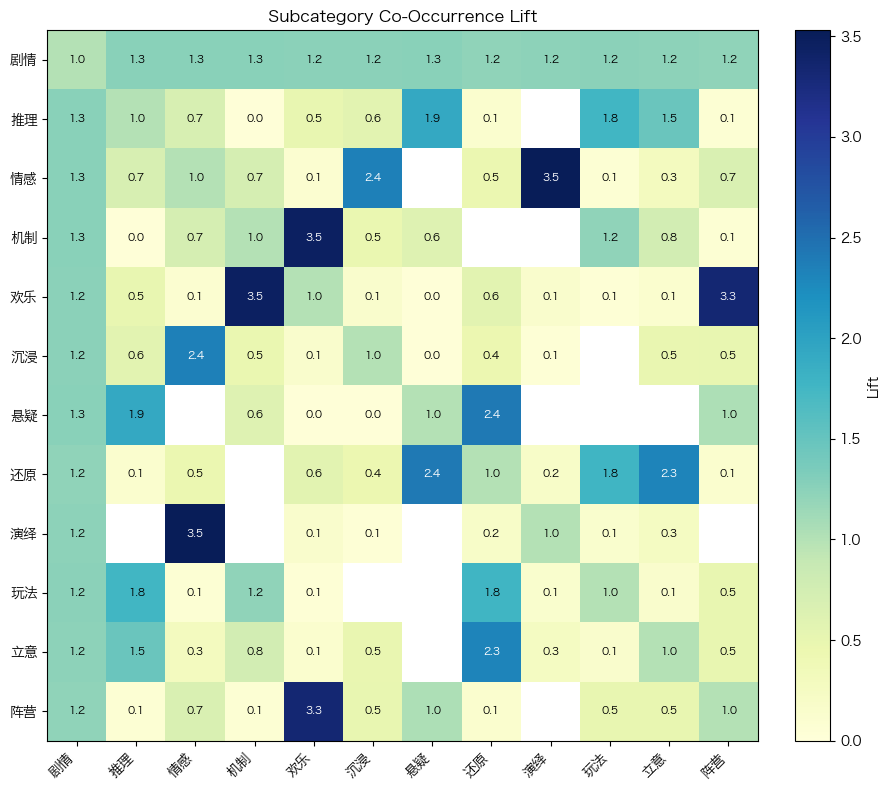

In [209]:
lift_matrix = pd.DataFrame(
    np.nan,
    index=active_subcategory_columns,
    columns=active_subcategory_columns,
)

for col in active_subcategory_columns:
    lift_matrix.loc[col, col] = 1.0

for _, row in subcategory_pair_cooccurrence.iterrows():
    lift_matrix.loc[row["left"], row["right"]] = row["lift"]
    lift_matrix.loc[row["right"], row["left"]] = row["lift"]

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(lift_matrix, vmin=0, vmax=min(4, np.nanmax(lift_matrix.values)), cmap="YlGnBu")
ax.set_xticks(range(len(active_subcategory_columns)))
ax.set_xticklabels(active_subcategory_columns, rotation=45, ha="right")
ax.set_yticks(range(len(active_subcategory_columns)))
ax.set_yticklabels(active_subcategory_columns)
ax.set_title("Subcategory Co-Occurrence Lift")

for row_idx in range(len(active_subcategory_columns)):
    for col_idx in range(len(active_subcategory_columns)):
        lift_value = lift_matrix.iloc[row_idx, col_idx]
        if pd.notna(lift_value):
            ax.text(
                col_idx,
                row_idx,
                f"{lift_value:.1f}",
                ha="center",
                va="center",
                color="white" if lift_value >= 2 else "black",
                fontsize=8,
            )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Lift")
fig.tight_layout()

In [210]:
subcategory_sets = subcategory_presence.apply(
    lambda row: tuple(row.index[row].tolist()),
    axis=1,
)

subcategory_combination_counts = (
    subcategory_sets[subcategory_sets.map(len).gt(0)]
    .value_counts()
    .rename_axis("subcategory_set")
    .to_frame("script_count")
    .reset_index()
)
subcategory_combination_counts["set_size"] = subcategory_combination_counts["subcategory_set"].map(len)
subcategory_combination_counts["script_pct"] = (
    subcategory_combination_counts["script_count"] / len(subcategory_presence) * 100
)
subcategory_combination_counts["subcategory_set"] = subcategory_combination_counts["subcategory_set"].map(
    lambda values: " + ".join(values)
)
subcategory_combination_counts.head(20)

,subcategory_set,script_count,set_size,script_pct
0,剧情 + 推理 + 悬疑,181,3,8.586
1,剧情 + 情感 + 沉浸,175,3,8.302
2,剧情 + 机制 + 欢乐,166,3,7.875
3,剧情 + 推理,156,2,7.400
4,剧情 + 推理 + 情感,133,3,6.309
5,剧情 + 情感 + 演绎,124,3,5.882
6,剧情 + 推理 + 玩法,74,3,3.510
7,剧情 + 情感 + 机制,61,3,2.894
8,剧情 + 推理 + 立意,61,3,2.894
9,剧情 + 推理 + 沉浸,55,3,2.609


### Interpretation

The most common exact subcategory bundles are `剧情 + 推理 + 悬疑` (181 scripts), `剧情 + 情感 + 沉浸` (175), and `剧情 + 机制 + 欢乐` (166). These three bundles map neatly onto mystery, emotional/immersive, and mechanism/fun script positioning.


## Metadata Parsing


In [211]:
import re

CHINESE_NUMERAL_MAP = {
    "零": 0,
    "一": 1,
    "二": 2,
    "两": 2,
    "三": 3,
    "四": 4,
    "五": 5,
    "六": 6,
    "七": 7,
    "八": 8,
    "九": 9,
    "十": 10,
}


def parse_chinese_number(value):
    if not isinstance(value, str) or not value:
        return None
    if value.isdigit():
        return float(value)
    if value in CHINESE_NUMERAL_MAP:
        return float(CHINESE_NUMERAL_MAP[value])
    if "十" in value:
        left, _, right = value.partition("十")
        tens = CHINESE_NUMERAL_MAP.get(left, 1) if left else 1
        ones = CHINESE_NUMERAL_MAP.get(right, 0) if right else 0
        return float(tens * 10 + ones)
    return None


def parse_numeric_token(value):
    if value is None:
        return None
    value = str(value).strip()
    if not value:
        return None
    try:
        return float(value)
    except ValueError:
        return parse_chinese_number(value)


def parse_metadata(metadata):
    text = "" if pd.isna(metadata) else str(metadata)

    gender_match = re.search(r"(\d+)\s*男\s*(\d+)\s*女", text)
    if not gender_match:
        gender_match = re.search(r"([零一二两三四五六七八九十]+)\s*男\s*([零一二两三四五六七八九十]+)\s*女", text)

    male_count = parse_numeric_token(gender_match.group(1)) if gender_match else np.nan
    female_count = parse_numeric_token(gender_match.group(2)) if gender_match else np.nan
    total_players_from_gender = male_count + female_count if pd.notna(male_count) and pd.notna(female_count) else np.nan

    total_players_match = re.search(r"(\d+)\s*人(?:本)?", text)
    if not total_players_match:
        total_players_match = re.search(r"([零一二两三四五六七八九十]+)\s*人(?:本)?", text)
    total_players_mentioned = parse_numeric_token(total_players_match.group(1)) if total_players_match else np.nan

    duration_match = re.search(r"(\d+(?:\.\d+)?)\s*(?:个)?\s*(?:小时|h|H)", text)
    if not duration_match:
        duration_match = re.search(r"([零一二两三四五六七八九十]+(?:点[零一二两三四五六七八九十]+)?)\s*(?:个)?\s*(?:小时|h|H)", text)
    if duration_match:
        duration_token = duration_match.group(1).replace("点", ".")
        if "." in duration_token and not duration_token.replace(".", "").isdigit():
            left, right = duration_token.split(".", 1)
            left_number = parse_chinese_number(left)
            right_number = parse_chinese_number(right)
            duration_hours = left_number + right_number / 10 if left_number is not None and right_number is not None else np.nan
        else:
            duration_hours = parse_numeric_token(duration_token)
    else:
        duration_hours = np.nan

    difficulty_match = re.search(r"(新手|进阶|高阶)", text)
    difficulty = difficulty_match.group(1) if difficulty_match else pd.NA

    release_match = re.search(r"(20\d{2})[.年/-](\d{1,2})?\s*(?:发行)?", text)
    release_year = float(release_match.group(1)) if release_match else np.nan
    release_month = float(release_match.group(2)) if release_match and release_match.group(2) else np.nan

    return pd.Series(
        {
            "male_count": male_count,
            "female_count": female_count,
            "total_players_from_gender": total_players_from_gender,
            "total_players_mentioned": total_players_mentioned,
            "duration_hours": duration_hours,
            "difficulty": difficulty,
            "release_year": release_year,
            "release_month": release_month,
        }
    )


In [212]:
metadata_parsed = ratings_clean["metadata"].apply(parse_metadata)
ratings_with_metadata = pd.concat([ratings_clean.copy(), metadata_parsed], axis=1)

for col in ["male_count", "female_count", "total_players_from_gender", "total_players_mentioned", "release_year", "release_month"]:
    ratings_with_metadata[col] = ratings_with_metadata[col].round().astype("Int64")

ratings_with_metadata["total_players"] = ratings_with_metadata["total_players_from_gender"].fillna(
    ratings_with_metadata["total_players_mentioned"]
).astype("Int64")

release_date = pd.Series(pd.NaT, index=ratings_with_metadata.index, dtype="datetime64[ns]")
has_release_year = ratings_with_metadata["release_year"].notna()
release_year_text = ratings_with_metadata.loc[has_release_year, "release_year"].astype(int).astype(str)
release_month_text = ratings_with_metadata.loc[has_release_year, "release_month"].fillna(1).astype(int).astype(str).str.zfill(2)
release_date.loc[has_release_year] = pd.to_datetime(
    release_year_text + "-" + release_month_text + "-01",
    errors="coerce",
)
ratings_with_metadata["release_date"] = release_date

parsed_metadata_columns = [
    "query", "script_title", "metadata", "male_count", "female_count", "total_players",
    "duration_hours", "difficulty", "release_year", "release_month", "release_date",
]
ratings_with_metadata[parsed_metadata_columns].head(20)


,query,script_title,metadata,male_count,female_count,total_players,duration_hours,difficulty,release_year,release_month,release_date
1,蜕变俱乐部2,蜕变俱乐部2：海的女儿,4男3女 4.0小时 高阶 2020.08发行,4,3,7,4.000,高阶,2020,8,2020-08-01
2,今夕何夕,今夕何夕,5男2女 4.5小时 进阶 2020.08发行,5,2,7,4.500,进阶,2020,8,2020-08-01
3,蜕变俱乐部,蜕变俱乐部,4男3女 5.0小时 高阶 2020.06发行,4,3,7,5.000,高阶,2020,6,2020-06-01
4,土狗,土狗,4男2女 7.0小时 进阶 2025.06发行,4,2,6,7.000,进阶,2025,6,2025-06-01
12,雉双归,雉双归,【5小时/令翼/没有边缘/体验分：8分】 ✅一句话总结：宝藏盒装有机会快来补课呀！ 『🌟关键...,<NA>,<NA>,<NA>,5.000,<NA>,<NA>,<NA>,NaT
14,俞家旅店,俞家旅店,3男1女 2.0小时 新手,3,1,4,2.000,新手,<NA>,<NA>,NaT
16,你还有遗憾吗,你还有遗憾吗,2男4女 4.5小时 新手 2021.08发行,2,4,6,4.500,新手,2021,8,2021-08-01
18,兔子的世界下起了胡萝卜雨,兔子的世界下起了胡萝卜雨,3男3女 4.5小时 新手,3,3,6,4.500,新手,<NA>,<NA>,NaT
19,将死未死的THX,将死未死的THX,【将死未死的THX】反转／推理／还原／悬疑 【角色时长】眼镜男／7小时 【人数配置】4男2女...,4,2,6,7.000,<NA>,<NA>,<NA>,NaT
20,大雪侦探和倒霉蛋,大雪，侦探和倒霉蛋,3男3女 6.0小时 高阶 2022.06发行,3,3,6,6.000,高阶,2022,6,2022-06-01


### Interpretation

The parser successfully extracts structured fields from both compact metadata strings and many noisy text snippets. The preview confirms that common patterns like `4男3女 4.0小时 高阶 2020.08发行` become usable variables for players, duration, difficulty, and release date.


In [213]:
metadata_fields = [
    "male_count", "female_count", "total_players", "duration_hours", "difficulty",
    "release_year", "release_month", "release_date",
]

metadata_parse_coverage = (
    ratings_with_metadata[metadata_fields]
    .notna()
    .sum()
    .to_frame("parsed_count")
    .assign(parsed_pct=lambda x: x["parsed_count"] / len(ratings_with_metadata) * 100)
    .sort_values("parsed_count", ascending=False)
)
metadata_parse_coverage


,parsed_count,parsed_pct
duration_hours,2096,99.431
total_players,2062,97.818
male_count,2056,97.533
female_count,2056,97.533
difficulty,1894,89.848
release_year,1564,74.194
release_date,1564,74.194
release_month,1562,74.099


### Interpretation

Metadata parsing coverage is high for duration and player fields: `duration_hours` is parsed for 99.4% of scripts, `total_players` for 97.8%, and gender counts for 97.5%. Difficulty is available for 89.8%. Release timing is less complete but still useful, with release year/date parsed for 74.2% of scripts.


In [214]:
metadata_summary_tables = {
    "difficulty": ratings_with_metadata["difficulty"].value_counts(dropna=False).rename_axis("difficulty").to_frame("rows"),
    "total_players": ratings_with_metadata["total_players"].value_counts(dropna=False).sort_index().rename_axis("total_players").to_frame("rows"),
    "release_year": ratings_with_metadata["release_year"].value_counts(dropna=False).sort_index().rename_axis("release_year").to_frame("rows"),
}

for name, table in metadata_summary_tables.items():
    print()
    print(name)
    print(table.to_string())



difficulty
            rows
difficulty      
进阶          1231
新手           430
高阶           233
<NA>         214

total_players
               rows
total_players      
1                 2
3                 2
4                30
5               158
6              1243
7               399
8               176
9                26
10               22
12                1
14                1
20                2
<NA>             46

release_year
              rows
release_year      
2016             3
2017             5
2018            45
2019           130
2020           260
2021           426
2022           251
2023           173
2024            76
2025           130
2026            65
<NA>           544


In [215]:
def summarize_rating_by_group(df: pd.DataFrame, group_col: str, min_count: int = 10) -> pd.DataFrame:
    summary = (
        df.dropna(subset=[group_col])
        .groupby(group_col, observed=False)
        .agg(
            rows=("overall_rating", "size"),
            mean_overall_rating=("overall_rating", "mean"),
            median_overall_rating=("overall_rating", "median"),
            median_played_count=("played_count", "median"),
            median_review_count=("review_count", "median"),
        )
        .query("rows >= @min_count")
        .sort_values("mean_overall_rating", ascending=False)
    )
    return summary

rating_by_difficulty = summarize_rating_by_group(ratings_with_metadata, "difficulty")
rating_by_total_players = summarize_rating_by_group(ratings_with_metadata, "total_players")
rating_by_release_year = summarize_rating_by_group(ratings_with_metadata, "release_year")

print("Rating by difficulty")
display(rating_by_difficulty)
print("Rating by total players")
display(rating_by_total_players)
print("Rating by release year")
display(rating_by_release_year)


Rating by difficulty


,rows,mean_overall_rating,median_overall_rating,median_played_count,median_review_count
difficulty,,,,,
高阶,233,7.069,7.100,10390.000,285.000
进阶,1231,6.842,7.000,8844.000,243.000
新手,430,6.820,7.000,12583.500,612.500


Rating by total players


,rows,mean_overall_rating,median_overall_rating,median_played_count,median_review_count
total_players,,,,,
4,30,7.510,7.200,5073.500,226.500
6,1243,7.060,7.200,10855.000,508.000
7,399,6.754,6.800,10175.000,230.000
5,158,6.587,6.700,8070.000,138.000
8,176,6.545,6.500,10011.500,200.500
10,22,5.955,6.200,18302.500,303.500
9,26,5.742,6.100,4204.500,98.000


Rating by release year


,rows,mean_overall_rating,median_overall_rating,median_played_count,median_review_count
release_year,,,,,
2026,65,7.651,7.800,7597.000,1189.000
2024,76,7.408,7.650,21843.000,2066.000
2025,130,7.313,7.300,10217.000,1292.500
2022,251,7.283,7.300,14916.500,653.000
2023,173,7.262,7.300,14180.000,1109.000
2021,426,6.694,6.800,13036.500,299.000
2019,130,6.673,6.550,6097.000,87.000
2020,260,6.608,6.600,10900.500,155.000
2018,45,6.464,6.600,5236.000,74.000


In [216]:
ratings_with_metadata["duration_bin"] = pd.cut(
    ratings_with_metadata["duration_hours"],
    bins=[0, 3, 4, 5, 6, 8, np.inf],
    labels=["<=3h", "3-4h", "4-5h", "5-6h", "6-8h", ">8h"],
    right=True,
)

rating_by_duration = summarize_rating_by_group(ratings_with_metadata, "duration_bin")
rating_by_duration


,rows,mean_overall_rating,median_overall_rating,median_played_count,median_review_count
duration_bin,,,,,
>8h,37,8.024,8.100,15295.000,2064.000
6-8h,196,7.715,7.800,21240.000,2817.500
5-6h,220,7.458,7.500,17266.500,1312.000
4-5h,1077,6.767,6.900,6559.000,172.000
3-4h,511,6.623,6.700,11944.000,283.000
<=3h,55,6.422,6.500,3742.000,118.000


### Interpretation

Difficulty differences are modest: `高阶` scripts have the highest mean rating (7.07), while `进阶` and `新手` are close together around 6.84 and 6.82. Player count shows a clearer pattern: 6-player scripts are common and relatively strong (mean 7.06), while 9- and 10-player scripts have lower means around 5.74-5.96.

Release-year summaries suggest newer scripts rate higher in this sample: 2026, 2024, and 2025 have the highest mean ratings, while 2018-2021 sit lower. Duration shows the strongest descriptive gradient: scripts longer than 8 hours average 8.02, 6-8 hour scripts average 7.72, and scripts of 3 hours or less average 6.42.


## Export Analysis Dataset


In [217]:
export_df = ratings_with_metadata.copy()

want_count = export_df["want_count"]
export_df["suspicious_want_count"] = (
    want_count.notna()
    & want_count.gt(0)
    & (want_count.lt(100) | ~np.isclose(want_count, np.round(want_count)))
)
export_df["usable_for_popularity_analysis"] = ~export_df["suspicious_want_count"]

export_df = export_df.reset_index(names="merged_row_index")

EXPORT_PATH = Path("ratings_analysis_dataset.csv")
export_df.to_csv(EXPORT_PATH, index=False, encoding="utf-8-sig")

print(f"Exported {len(export_df):,} rows and {export_df.shape[1]:,} columns to {EXPORT_PATH}")
print(f"Suspicious want_count rows flagged: {export_df['suspicious_want_count'].sum():,}")


Exported 2,108 rows and 45 columns to ratings_analysis_dataset.csv
Suspicious want_count rows flagged: 920


### Interpretation

Running the export cell will write the 2,108-row analysis dataset used here, including parsed metadata fields and the `suspicious_want_count` / `usable_for_popularity_analysis` flags. This keeps the exported dataset aligned with the exact cleaning decisions in the notebook.


## Future Implementation Plan

- `want_count` needs a future cleaning step. For now, positive values below 100 and positive fractional values are excluded because manual checks suggest they are unreliable random values.
- Use the parsed metadata fields as controls and descriptive grouping variables: total players, gender composition, duration, difficulty, and release date.
- Clean `tags` into one tag per row, then summarize rating and popularity by tag and by publisher.
- Use LLM-assisted coding to generate additional script-level features, such as authenticity and engagement scores from text fields or scraped descriptions when available.
- After feature construction, run regression models with `overall_rating` as the outcome and predictors such as popularity, parsed metadata fields, tag indicators, publisher indicators, and LLM-derived authenticity/engagement scores.
